In [7]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.optimizers import Adam
import mediapipe as mp
import random

In [8]:
gesture_folder = '/Users/4star/Downloads/Gesture Recognition/Gesture Image Data'

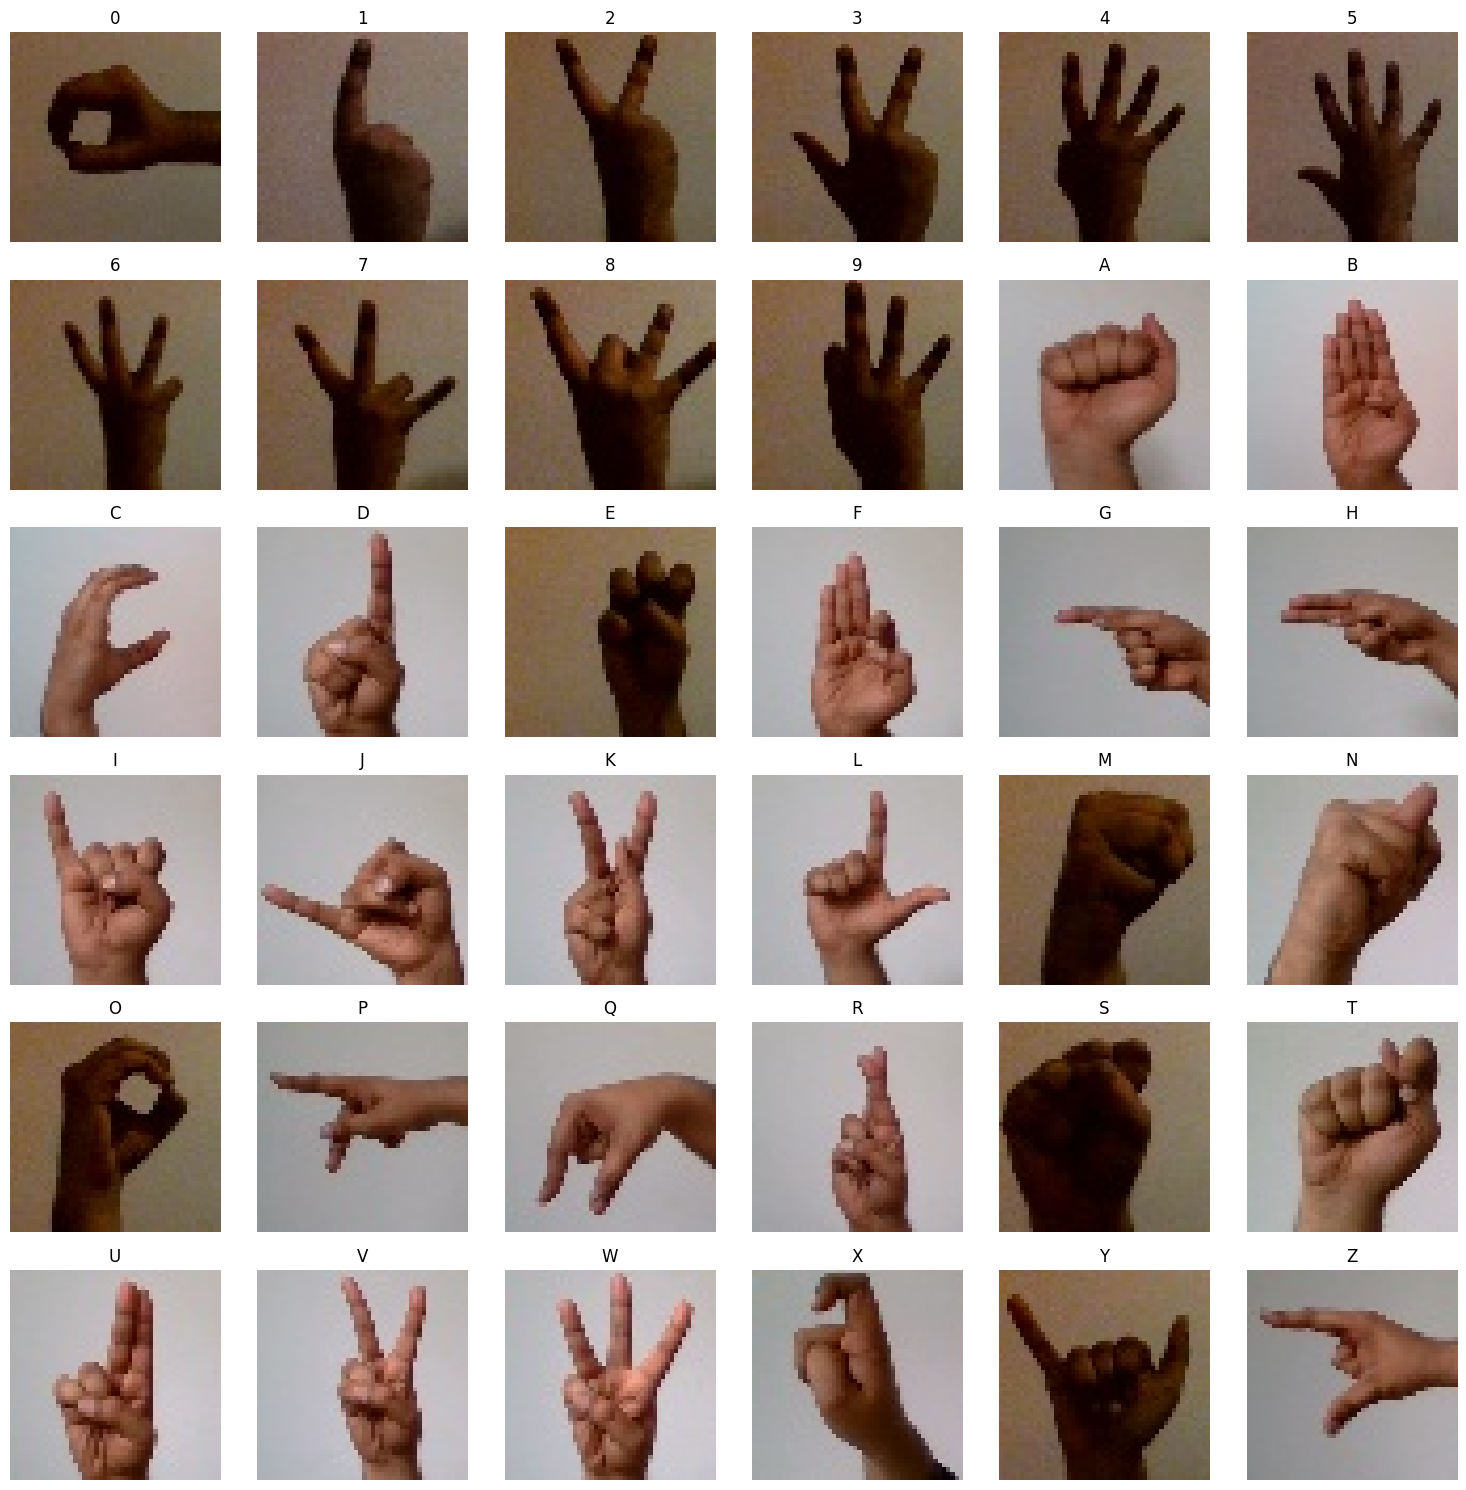

In [9]:
# List subfolders and sort them
subfolders = sorted(os.listdir(gesture_folder))

# Calculate grid size based on the number of subfolders
num_subfolders = len(subfolders)
grid_cols = 6
grid_rows = -(-num_subfolders // grid_cols)  # Ceiling division

# Create a grid for displaying images
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(15, grid_rows * 2.5))
axes = axes.flatten()

for i, subfolder in enumerate(subfolders):
    subfolder_path = os.path.join(gesture_folder, subfolder)
    if os.path.isdir(subfolder_path):  # Check if it's a folder
        image_files = os.listdir(subfolder_path)
        if image_files:  # Ensure there are images in the folder
            # Load the first image
            image_path = os.path.join(subfolder_path, image_files[3])
            image = cv2.imread(image_path)
            if image is not None:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                axes[i].imshow(image)
                axes[i].axis('off')
                axes[i].set_title(subfolder)

# Hide remaining axes if there are unused grid spaces
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [10]:
# Parameters
input_shape = (64, 64, 3)  # Image dimensions (height, width, channels)
num_classes = 36 # Update this to match the number of gestures in your dataset
batch_size = 64
epochs = 10

# Data Augmentation and Data Loading
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # Split for validation
)

train_generator = train_datagen.flow_from_directory(
    "/Users/4star/Downloads/Gesture Recognition/Gesture Image Data",
    target_size=(64, 64),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    "/Users/4star/Downloads/Gesture Recognition/Gesture Image Data",
    target_size=(64, 64),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

# CNN Model Architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # Output layer
])

model.summary()
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Checkpoint to save the best model
checkpoint = ModelCheckpoint(
    "gesture_model.keras",  # Save path
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[checkpoint]
)

# Save the final model
model.save("gesture_model_final.keras")

Found 43200 images belonging to 36 classes.
Found 10800 images belonging to 36 classes.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,282,404 (4.89 MB)

 Trainable params: 1,282,404 (4.89 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.2977 - loss: 2.3103
Epoch 1: val_accuracy improved from -inf to 0.89472, saving model to gesture_model.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 139s 202ms/step - accuracy: 0.2980 - loss: 2.3091 - val_accuracy: 0.8947 - val_loss: 0.3645
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.8243 - loss: 0.5074
Epoch 2: val_accuracy improved from 0.89472 to 0.95194, saving model to gesture_model.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 135s 200ms/step - accuracy: 0.8244 - loss: 0.5073 - val_accuracy: 0.9519 - val_loss: 0.1508
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.8997 - loss: 0.2930
Epoch 3: val_accuracy improved from 0.95194 to 0.96204, saving model to gesture_model.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 140s 207ms/step - accuracy: 0.8997 - loss: 0.2930 - val_accuracy: 0.9620 - val_loss: 0.1161
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9283 - loss: 0.2141
Epoch 4: val

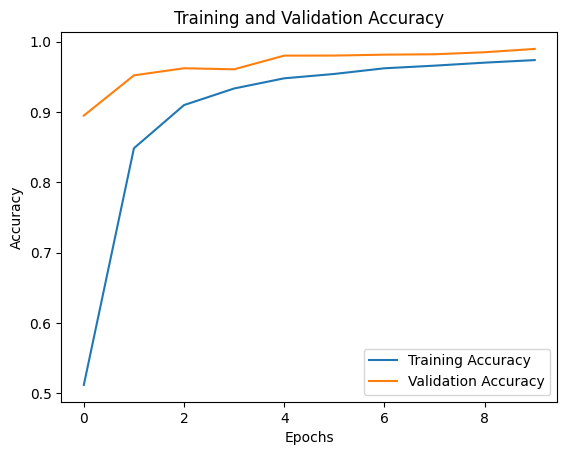

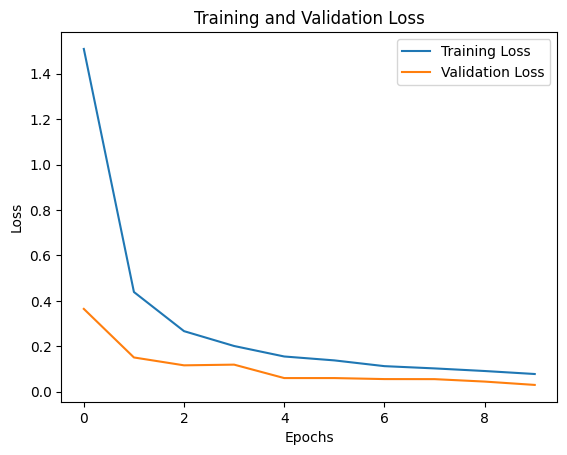

In [11]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [12]:
gesture_labels = sorted(os.listdir('/Users/4star/Downloads/Gesture Recognition/Gesture Image Data'))
print("Gesture Labels:", gesture_labels)

Gesture Labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [13]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

# Load the saved model
model = load_model("gesture_model_final.keras")

In [14]:
import os
import numpy as np
from keras.preprocessing.image import load_img, img_to_array
from keras.models import load_model

# Function to resize and normalize images
def preprocess_image(image_path, target_size=(64, 64)):
    # Load the image
    img = load_img(image_path, target_size=target_size)

    # Convert the image to a NumPy array and normalize
    img_array = img_to_array(img) / 255.0  # Normalize to range [0, 1]

    # Add a batch dimension (required for prediction)
    img_array = np.expand_dims(img_array, axis=0)

    return img_array

# Function to process all images in a folder
def process_folder(folder_path, target_size=(64, 64)):
    processed_images = []
    image_names = []

    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)

        if os.path.isfile(file_path) and file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            try:
                processed_image = preprocess_image(file_path, target_size)
                processed_images.append(processed_image)
                image_names.append(file_name)
            except Exception as e:
                print(f"Error processing image {file_name}: {e}")

    return processed_images, image_names

# Path to the folder containing test images
test_folder_path = "/Users/4star/Downloads/Gesture Recognition/Gesture Image Data"

# Process all images in the folder
processed_images, image_names = process_folder(test_folder_path)

model = load_model("gesture_model_final.keras")



# Perform predictions
print(f"Predicting labels for {len(processed_images)} images.")
for name, img in zip(image_names, processed_images):
    prediction = model.predict(img, verbose=0)  # Predict
    predicted_label_index = np.argmax(prediction)  # Get index of the highest probability
    # FIX: gesture_labels is a list, use indexing not .get()
    predicted_label = gesture_labels[predicted_label_index]
    print(f"Image {name}: Predicted Label: {predicted_label}")


Predicting labels for 0 images.


In [15]:
# Load your trained model
from tensorflow.keras.models import load_model

# Load the saved model (ensure the path is correct)
model = load_model("gesture_model_final.keras")

# FIX: Call process_folder function properly and stack images
if len(processed_images) > 0:
    predictions = model.predict(np.vstack(processed_images), verbose=0)
    
    # Get the predicted class indices
    predicted_label_indices = np.argmax(predictions, axis=1)
    
    # Map the indices back to the class names
    class_names = {v: k for k, v in train_generator.class_indices.items()}  # Reverse mapping
    
    # Output the results for all images
    for i, predicted_label_index in enumerate(predicted_label_indices):
        predicted_class = class_names[predicted_label_index]
        print(f"Image {image_names[i]}: Predicted Class: {predicted_class}, Confidence: {predictions[i][predicted_label_index]:.2f}")
else:
    print("No images to process")


No images to process


In [16]:
# Check the class indices from the training data generator
print("Class Indices from Training:", train_generator.class_indices)

# Reverse the dictionary to map indices to class names
class_names = {v: k for k, v in train_generator.class_indices.items()}
print("Mapped Class Names:", class_names)


Class Indices from Training: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, 'A': 10, 'B': 11, 'C': 12, 'D': 13, 'E': 14, 'F': 15, 'G': 16, 'H': 17, 'I': 18, 'J': 19, 'K': 20, 'L': 21, 'M': 22, 'N': 23, 'O': 24, 'P': 25, 'Q': 26, 'R': 27, 'S': 28, 'T': 29, 'U': 30, 'V': 31, 'W': 32, 'X': 33, 'Y': 34, 'Z': 35}
Mapped Class Names: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'A', 11: 'B', 12: 'C', 13: 'D', 14: 'E', 15: 'F', 16: 'G', 17: 'H', 18: 'I', 19: 'J', 20: 'K', 21: 'L', 22: 'M', 23: 'N', 24: 'O', 25: 'P', 26: 'Q', 27: 'R', 28: 'S', 29: 'T', 30: 'U', 31: 'V', 32: 'W', 33: 'X', 34: 'Y', 35: 'Z'}


In [17]:
# Get class indices from training generator
class_indices = train_generator.class_indices
# Reverse the dictionary to map indices to class names
class_names = {v: k for k, v in class_indices.items()}
testing_folder = "/Users/4star/Downloads/Gesture Recognition/Gesture Image Data"

# Example: Map predicted label to class name
for filename in os.listdir(testing_folder):
    if filename.endswith(".jpg") or filename.endswith(".png"):
        file_path = os.path.join(testing_folder, filename)
        # Use the preprocess_image function defined earlier
        img = preprocess_image(file_path)
        predictions = model.predict(img, verbose=0)
        predicted_index = np.argmax(predictions[0])
        class_name = class_names[predicted_index]
        confidence = predictions[0][predicted_index]
        print(f"Image: {filename}, Predicted Class: {class_name}, Confidence: {confidence:.4f}")


In [ ]:
import random

# Load a random image from the dataset
gesture_folder = '/Users/4star/Downloads/Gesture Recognition/Gesture Image Data'

# Pick a random subfolder (gesture label)
random_label = random.choice(sorted(os.listdir(gesture_folder)))
subfolder_path = os.path.join(gesture_folder, random_label)

# Pick a random image from the subfolder
random_image_file = random.choice(os.listdir(subfolder_path))
random_image_path = os.path.join(subfolder_path, random_image_file)

# Load and preprocess the random image
image = cv2.imread(random_image_path)
image_resized = cv2.resize(image, (64, 64))
image_normalized = np.array(image_resized, dtype='float32') / 255.0  # Normalize
image_input = np.expand_dims(image_normalized, axis=0)  # Add batch dimension

# Predict the gesture
predictions = model.predict(image_input, verbose=0)
predicted_index = np.argmax(predictions[0])
predicted_label = gesture_labels[predicted_index]

# Display the original label and the predicted label
print(f"Original Label: {random_label}")
print(f"Predicted Label: {predicted_label}")

# Display the image for visual verification
cv2.imshow('Random Test Image', image)
cv2.waitKey(0)
cv2.destroyAllWindows()


Original Label: K
Predicted Label: P


In [1]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
import mediapipe as mp
import os

# Load the trained model
model = load_model('gesture_model_final.keras')

# Define gesture labels (corresponding to your dataset folder names)
gesture_labels = sorted(os.listdir('/Users/4star/Downloads/Gesture Recognition/Gesture Image Data'))

# Set image dimensions
IMG_HEIGHT, IMG_WIDTH = 64, 64

# Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
hands = mp_hands.Hands(static_image_mode=False,
                       max_num_hands=1,
                       min_detection_confidence=0.7,
                       min_tracking_confidence=0.7)

# Start video capture
cap = cv2.VideoCapture(0)  # Use webcam (default is 0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Flip the frame for a mirror view
    frame = cv2.flip(frame, 1)

    # Convert the frame to RGB
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Process the frame with MediaPipe
    results = hands.process(rgb_frame)

    # If a hand is detected
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            # Draw hand landmarks on the frame
            mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

            # Get the bounding box of the hand
            h, w, _ = frame.shape
            x_min = int(min([lm.x for lm in hand_landmarks.landmark]) * w)
            x_max = int(max([lm.x for lm in hand_landmarks.landmark]) * w)
            y_min = int(min([lm.y for lm in hand_landmarks.landmark]) * h)
            y_max = int(max([lm.y for lm in hand_landmarks.landmark]) * h)

            # Ensure bounding box is within frame boundaries
            x_min = max(0, x_min)
            y_min = max(0, y_min)
            x_max = min(w, x_max)
            y_max = min(h, y_max)

            # Crop the hand region
            hand_roi = frame[y_min:y_max, x_min:x_max]

            # Preprocess the hand ROI
            if hand_roi.size > 0:
                hand_roi = cv2.resize(hand_roi, (IMG_HEIGHT, IMG_WIDTH))
                hand_roi = np.array(hand_roi, dtype='float32') / 255.0  # Normalize
                hand_roi = np.expand_dims(hand_roi, axis=0)  # Add batch dimension

                # Validate the model with test images (for debugging)
                predictions = model.predict(hand_roi, verbose=0)
                predicted_index = np.argmax(predictions[0])
                predicted_label = gesture_labels[predicted_index]

                # Display the original label and prediction
                print(f"Predicted Gesture: {predicted_label}")

                # Display the result on the video frame
                cv2.putText(frame, f"Gesture: {predicted_label}", (x_min, y_min - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # Show the frame
    cv2.imshow('Gesture Recognition', frame)

    # Break on 'q' key press
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the capture and close windows
cap.release()
cv2.destroyAllWindows()


2026-06-14 14:57:41.943414: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781431071.135606  427841 gl_context.cc:369] GL version: 2.1 (2.1 ATI-7.0.24), renderer: AMD Radeon Pro 560X OpenGL Engine
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1781431071.164739  428042 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781431071.190388  428042 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781431076.406085  428036 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only support

Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: 5
Predicted Gesture: 5
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: 5
Predicted Gesture: 5
Predicted Gesture: 5
Predicted Gesture: 5
Predicted Gesture: 5
Predicted Gesture: 5
Predicted Gesture: 5
Predicted Gesture: 5
Predicted Gesture: 5
Predicted Gesture: 5
Predicted Gesture: P
Predicted Gesture: 5
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Gesture: P
Predicted Ges

KeyboardInterrupt: 